In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('LoanDataset.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df = df.dropna()
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [7]:
df['Dependents'].value_counts()

Dependents
0     274
2      85
1      80
3+     41
Name: count, dtype: int64

In [8]:
df.replace(to_replace='3+', value=4, inplace=True)

In [9]:
df['Dependents'].value_counts()

Dependents
0    274
2     85
1     80
4     41
Name: count, dtype: int64

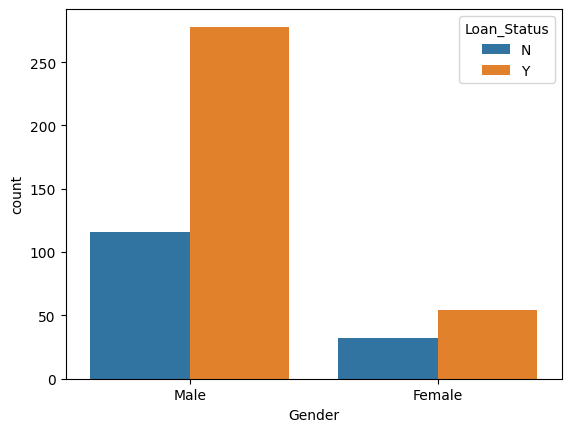

In [10]:
sns.countplot(x='Gender' , data=df, hue='Loan_Status');

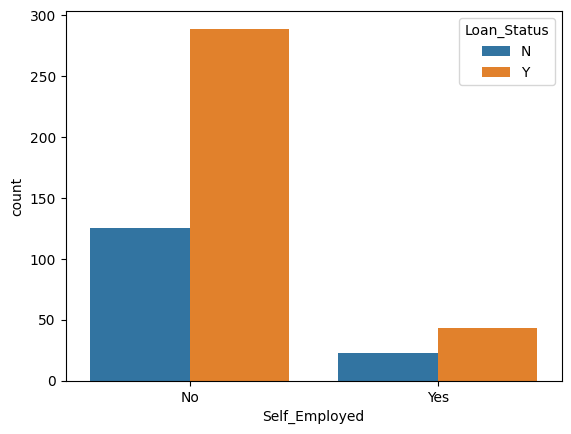

In [11]:
sns.countplot(x='Self_Employed' , data=df, hue='Loan_Status');

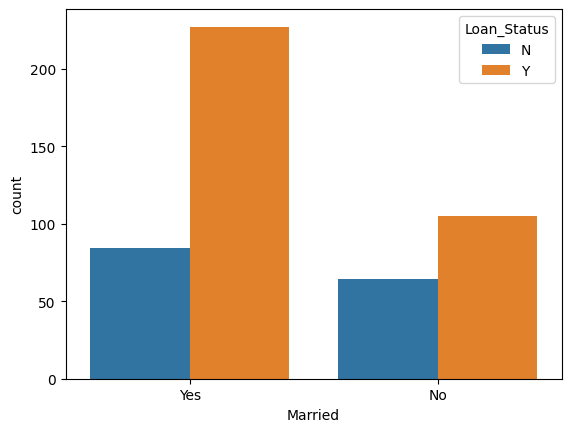

In [12]:
sns.countplot(x='Married' , data=df, hue='Loan_Status');

In [13]:
df['Loan_Status'].value_counts()

Loan_Status
Y    332
N    148
Name: count, dtype: int64

In [25]:
df.replace({'Married': {'No': 0, 'Yes': 1}, 
            'Gender': {'Male': 1, 'Female': 0}, 
            'Property_Area': {'Semiurban': 1, 'Urban': 2, 'Rural': 3}, 
            'Education': {'Graduate': 1, 'Not Graduate': 0}, 
            'Self_Employed': {'No': 0, 'Yes': 1},
            'Loan_Status': {'N': 0, 'Y': 1}}, inplace=True)

# Explicitly infer objects to handle future downcasting behavior
# df = df.infer_objects()

/var/folders/qd/qn1n_4h10qx7fwk4cm80nntc0000gn/T/ipykernel_98200/1878627168.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Married': {'No': 0, 'Yes': 1},


In [26]:
df['Loan_Status'].value_counts()

Loan_Status
1    332
0    148
Name: count, dtype: int64

In [27]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,3,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


In [28]:
X = df.drop(['Loan_Status', 'Loan_ID'], axis=1)
y = df['Loan_Status']

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [37]:
logistic_regression = LogisticRegression(max_iter=1000, solver='liblinear')
logistic_regression.fit(X_train, y_train)
lr_pred_train = logistic_regression.predict(X_train)
lr_pred = logistic_regression.predict(X_test)

print('Training Accuracy:', accuracy_score(y_train, lr_pred_train))
print('Testing Accuracy:', accuracy_score(y_test, lr_pred))

Training Accuracy: 0.8046875
Testing Accuracy: 0.8229166666666666


In [45]:
decision_tree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=12)
decision_tree.fit(X_train, y_train)
dt_pred_train = decision_tree.predict(X_train)
dt_pred_test = decision_tree.predict(X_test)

print('Training Accuracy:', accuracy_score(y_train, dt_pred_train))
print('Testing Accuracy:', accuracy_score(y_test, dt_pred_test))

Training Accuracy: 0.8333333333333334
Testing Accuracy: 0.78125


In [46]:
random_forest = RandomForestClassifier(n_estimators=50, max_depth=4, random_state=12)
random_forest.fit(X_train, y_train)
random_forest_pred_train = random_forest.predict(X_train)
random_forest_pred_test = random_forest.predict(X_test)

print('Training Accuracy:', accuracy_score(y_train, random_forest_pred_train))
print('Testing Accuracy:', accuracy_score(y_test, random_forest_pred_test))

Training Accuracy: 0.8125
Testing Accuracy: 0.8020833333333334


In [47]:
naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train)
nb_pred_train = naive_bayes.predict(X_train)
nb_pred_test = naive_bayes.predict(X_test)

print('Training Accuracy:', accuracy_score(y_train, nb_pred_train))
print('Testing Accuracy:', accuracy_score(y_test, nb_pred_test))

Training Accuracy: 0.7942708333333334
Testing Accuracy: 0.8229166666666666


In [48]:
svc = SVC(kernel='linear')
svc.fit(X_train, y_train)
svc_pred_train = svc.predict(X_train)
svc_pred_test = svc.predict(X_test)

print('Training Accuracy:', accuracy_score(y_train, svc_pred_train))
print('Testing Accuracy:', accuracy_score(y_test, svc_pred_test))

Training Accuracy: 0.8046875
Testing Accuracy: 0.8229166666666666


In [49]:
from sklearn.model_selection import cross_val_score
from skopt import gp_minimize
from skopt.space import Integer

In [56]:
# Objective function to minimize (hence the negative sign)
def objective(params):
    n_estimators, max_depth = params
    clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth)
    return -cross_val_score(clf, X, y, cv=3, scoring="accuracy").mean()


space = [Integer(10, 150, name='n_estimators'),
         Integer(1, 10, name='max_depth')]  


result = gp_minimize(objective,               
                     space,                   
                     acq_func="EI",           
                     n_calls=10,              
                     random_state=0)

# Best hyperparameters
print(f"Best parameters: {result.x}")

Best parameters: [np.int64(52), np.int64(2)]


In [65]:
random_forest = RandomForestClassifier(n_estimators=50, max_depth=4, random_state=12)
random_forest.fit(X_train, y_train)
random_forest_pred_train = random_forest.predict(X_train)
random_forest_pred_test = random_forest.predict(X_test)

print('Training Accuracy:', accuracy_score(y_train, random_forest_pred_train))
print('Testing Accuracy:', accuracy_score(y_test, random_forest_pred_test))

Training Accuracy: 0.8125
Testing Accuracy: 0.8020833333333334
